# Explainable Fake News Detection Using Transformer Models

This notebook contains the implementation of an explainable fake news detection system using the WELFake dataset. BERT, RoBERTa and ELECTRA are fine-tuned and evaluated under the same experimental conditions. The strongest-performing model, RoBERTa, is subsequently analysed using SHAP to examine the textual features influencing its predictions.

## 1. Environment Setup

In [1]:
!pip install -q transformers datasets accelerate evaluate shap 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.1 MB/s eta 0:00:00a 0:00:01


In [5]:
import torch
import pandas as pd
import numpy as np
import os
import glob
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    average_precision_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from scipy.special import softmax
import matplotlib.pyplot as plt

In [3]:
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [4]:
print("GPU available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

GPU available: True
Number of GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 2. Dataset Loading and Initial Analysis

### 2.1 Loading the WELFake Dataset

In [6]:
file_path = glob.glob('/kaggle/input/**/WELFake_Dataset.csv', recursive=True)[0]

print("Dataset path:", file_path)

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset path: /kaggle/input/datasets/moboluwadurogundimu/welfake-dataset/WELFake_Dataset.csv
Dataset loaded successfully.
Dataset shape: (72134, 4)


### 2.2 Initial Dataset Inspection

In [7]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [8]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (72134, 4)

Columns:
['Unnamed: 0', 'title', 'text', 'label']

Data types:
Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object

Missing values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


In [9]:
print("Label counts:")
print(df['label'].value_counts())

print("\nLabel percentages:")
print(df['label'].value_counts(normalize=True) * 100)

Label counts:
label
1    37106
0    35028
Name: count, dtype: int64

Label percentages:
label
1    51.440375
0    48.559625
Name: proportion, dtype: float64


### 2.3 Data Cleaning

In [11]:
# Remove the unnecessary index column if it exists
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Remove rows where the article text is missing
df = df.dropna(subset=['text'])

# Reset the dataframe index
df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after cleaning: (72095, 3)

Missing values:
title    558
text       0
label      0
dtype: int64


In [12]:
print("Duplicate text rows:", df.duplicated(subset=['text']).sum())

print("Duplicate title rows:", df.duplicated(subset=['title']).sum())

print("Fully duplicated rows:", df.duplicated().sum())

Duplicate text rows: 9377
Duplicate title rows: 9786
Fully duplicated rows: 8456


In [13]:
# Check whether identical article texts have different labels
label_counts_per_text = df.groupby('text')['label'].nunique()

conflicting_texts = label_counts_per_text[label_counts_per_text > 1]

print("Duplicate texts with conflicting labels:", len(conflicting_texts))

Duplicate texts with conflicting labels: 1


In [15]:
blank_texts = df['text'].astype(str).str.strip().eq('')

print("Blank article texts:", blank_texts.sum())

print("\nLabels of blank-text rows:")
print(df.loc[blank_texts, 'label'].value_counts())

Blank article texts: 744

Labels of blank-text rows:
label
1    743
0      1
Name: count, dtype: int64


In [16]:
# Remove rows containing blank article text
df = df[~blank_texts].copy()

# Reset index
df = df.reset_index(drop=True)

print("Dataset shape after removing blank texts:", df.shape)

print("\nBlank article texts remaining:",
      df['text'].astype(str).str.strip().eq('').sum())

Dataset shape after removing blank texts: (71351, 3)

Blank article texts remaining: 0


In [17]:
# Recheck duplicate article texts
duplicate_texts = df.duplicated(subset=['text']).sum()

# Recheck conflicting labels
label_counts_per_text = df.groupby('text')['label'].nunique()
conflicting_texts = label_counts_per_text[label_counts_per_text > 1]

print("Duplicate text rows:", duplicate_texts)
print("Duplicate texts with conflicting labels:", len(conflicting_texts))

Duplicate text rows: 8636
Duplicate texts with conflicting labels: 0


In [18]:
# Remove duplicate article texts, keeping the first occurrence
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)

print("Dataset shape after removing duplicate texts:", df.shape)

Dataset shape after removing duplicate texts: (62715, 3)


In [19]:
# Check class distribution after cleaning and deduplication
print("Label counts:")
print(df['label'].value_counts())

print("\nLabel percentages:")
print(df['label'].value_counts(normalize=True) * 100)

Label counts:
label
0    34620
1    28095
Name: count, dtype: int64

Label percentages:
label
0    55.202105
1    44.797895
Name: proportion, dtype: float64


## 3. Data Splitting and Token Analysis

In [20]:
from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

# Second split: divide temporary data equally into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

Training set: (50172, 3)
Validation set: (6271, 3)
Test set: (6272, 3)


In [21]:
print("Training label distribution:")
print(train_df['label'].value_counts(normalize=True) * 100)

print("\nValidation label distribution:")
print(val_df['label'].value_counts(normalize=True) * 100)

print("\nTest label distribution:")
print(test_df['label'].value_counts(normalize=True) * 100)

Training label distribution:
label
0    55.202105
1    44.797895
Name: proportion, dtype: float64

Validation label distribution:
label
0    55.206506
1    44.793494
Name: proportion, dtype: float64

Test label distribution:
label
0    55.197704
1    44.802296
Name: proportion, dtype: float64


In [22]:
# Load BERT tokenizer
bert_model_name = "bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

print("BERT tokenizer loaded successfully.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT tokenizer loaded successfully.


In [23]:
MAX_LENGTH = 512

def tokenize_texts(texts):
    return bert_tokenizer(
        texts.tolist(),
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

bert_train_encodings = tokenize_texts(train_df['text'])
bert_val_encodings = tokenize_texts(val_df['text'])
bert_test_encodings = tokenize_texts(test_df['text'])

print("Tokenisation complete at 512 tokens.")
print("Training examples:", len(bert_train_encodings['input_ids']))
print("Validation examples:", len(bert_val_encodings['input_ids']))
print("Test examples:", len(bert_test_encodings['input_ids']))

Tokenisation complete at 512 tokens.
Training examples: 50172
Validation examples: 6271
Test examples: 6272


In [24]:
token_lengths = [
    len(bert_tokenizer.encode(text, add_special_tokens=True, truncation=False))
    for text in df['text']
]

print("Average token length:", sum(token_lengths) / len(token_lengths))
print("Articles over 256 tokens:", sum(length > 256 for length in token_lengths))
print("Articles over 512 tokens:", sum(length > 512 for length in token_lengths))

print("\nPercentage over 256 tokens:",
      sum(length > 256 for length in token_lengths) / len(token_lengths) * 100)

print("Percentage over 512 tokens:",
      sum(length > 512 for length in token_lengths) / len(token_lengths) * 100)

Token indices sequence length is longer than the specified maximum sequence length for this model (1200 > 512). Running this sequence through the model will result in indexing errors


Average token length: 705.5569002630949
Articles over 256 tokens: 49908
Articles over 512 tokens: 31442

Percentage over 256 tokens: 79.57904807462329
Percentage over 512 tokens: 50.13473650641792


In [26]:
import numpy as np

print("90th percentile:", np.percentile(token_lengths, 90))
print("95th percentile:", np.percentile(token_lengths, 95))
print("99th percentile:", np.percentile(token_lengths, 99))
print("Maximum:", max(token_lengths))

90th percentile: 1420.0
95th percentile: 1807.0
99th percentile: 3540.8600000000006
Maximum: 118424


## 4. BERT Model Development and Evaluation

In [28]:
class FakeNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

bert_train_dataset = FakeNewsDataset(
    bert_train_encodings,
    train_df["label"]
)

bert_val_dataset = FakeNewsDataset(
    bert_val_encodings,
    val_df["label"]
)

bert_test_dataset = FakeNewsDataset(
    bert_test_encodings,
    test_df["label"]
)

print("Training dataset:", len(bert_train_dataset))
print("Validation dataset:", len(bert_val_dataset))
print("Test dataset:", len(bert_test_dataset))

Training dataset: 50172
Validation dataset: 6271
Test dataset: 6272


In [29]:
# Dynamic padding
bert_data_collator = DataCollatorWithPadding(
    tokenizer=bert_tokenizer
)

# Load BERT for binary classification
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=2
)

print("BERT classification model loaded successfully.")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT classification model loaded successfully.


In [30]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='weighted',
        zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("Evaluation metrics configured successfully.")

Evaluation metrics configured successfully.


In [31]:
!nvidia-smi

Mon Aug 24 01:18:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
bert_training_args = TrainingArguments(
    output_dir="/kaggle/working/bert_results",

    # Training
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # T4 memory management
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    fp16=True,

    # Evaluation and checkpoints
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Other settings
    logging_strategy="steps",
    logging_steps=500,
    save_total_limit=2,
    report_to="none",

    seed=42
)

In [33]:
bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,
    processing_class=bert_tokenizer,
    data_collator=bert_data_collator,
    compute_metrics=compute_metrics
)

print("BERT Trainer configured successfully.")

BERT Trainer configured successfully.


In [34]:
# Inspect one batch before training
sample_batch = bert_data_collator(
    [bert_train_dataset[i] for i in range(4)]
)

print("input_ids shape:", sample_batch["input_ids"].shape)
print("attention_mask shape:", sample_batch["attention_mask"].shape)
print("labels:", sample_batch["labels"])

input_ids shape: torch.Size([4, 512])
attention_mask shape: torch.Size([4, 512])
labels: tensor([1, 0, 0, 1])


In [35]:
bert_train_result = bert_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.342085,0.088045,0.991708,0.991726,0.991708,0.991705
2,0.155113,0.064113,0.994578,0.994578,0.994578,0.994578
3,0.025298,0.086275,0.994419,0.994423,0.994419,0.994418


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [36]:
print("Best checkpoint:", bert_trainer.state.best_model_checkpoint)
print("Best validation F1:", bert_trainer.state.best_metric)

Best checkpoint: /kaggle/working/bert_results/checkpoint-3136
Best validation F1: 0.9945780345889573


In [37]:
print("Current epoch:", bert_trainer.state.epoch)
print("Global training steps:", bert_trainer.state.global_step)

Current epoch: 3.0
Global training steps: 4704


In [38]:
bert_test_results = bert_trainer.evaluate(bert_test_dataset)

print(bert_test_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.0412265881896019, 'eval_accuracy': 0.9956951530612245, 'eval_precision': 0.9956957058133321, 'eval_recall': 0.9956951530612245, 'eval_f1': 0.9956947895877132, 'eval_runtime': 131.302, 'eval_samples_per_second': 47.768, 'eval_steps_per_second': 5.971, 'epoch': 3.0}


In [39]:
# Get BERT predictions on the test set
bert_predictions = bert_trainer.predict(bert_test_dataset)

# Convert logits to predicted classes
bert_pred_labels = np.argmax(bert_predictions.predictions, axis=1)

# True labels
bert_true_labels = test_df['label'].to_numpy()

print("Classification Report:")
print(
    classification_report(
        bert_true_labels,
        bert_pred_labels,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        bert_true_labels,
        bert_pred_labels
    )
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Classification Report:
              precision    recall  f1-score   support

           0     0.9954    0.9968    0.9961      3462
           1     0.9961    0.9943    0.9952      2810

    accuracy                         0.9957      6272
   macro avg     0.9957    0.9956    0.9956      6272
weighted avg     0.9957    0.9957    0.9957      6272


Confusion Matrix:
[[3451   11]
 [  16 2794]]


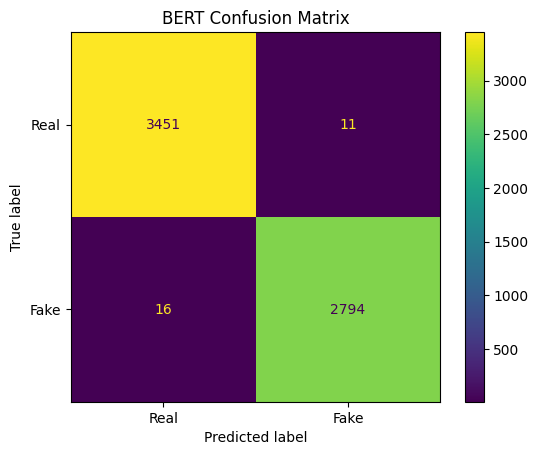

In [40]:
cm = confusion_matrix(
    bert_true_labels,
    bert_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(values_format='d')
plt.title("BERT Confusion Matrix")
plt.show()

BERT ROC-AUC: 0.9999045046267456


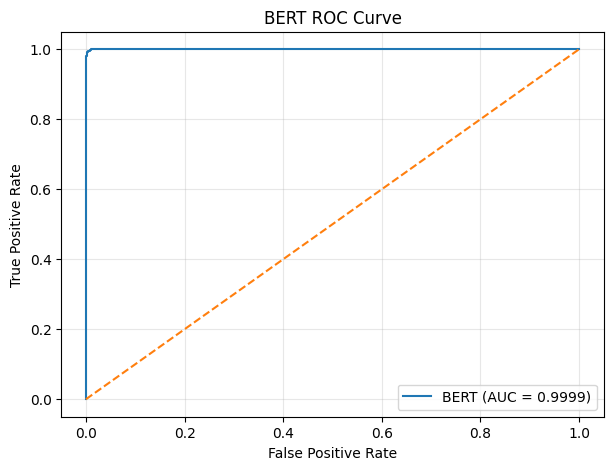

In [41]:
# Convert BERT logits to probabilities
bert_probabilities = softmax(
    bert_predictions.predictions,
    axis=1
)

# Probability of the positive class (Fake = 1)
bert_fake_prob = bert_probabilities[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    bert_true_labels,
    bert_fake_prob
)

# Calculate ROC-AUC
bert_roc_auc = roc_auc_score(
    bert_true_labels,
    bert_fake_prob
)

print("BERT ROC-AUC:", bert_roc_auc)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"BERT (AUC = {bert_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BERT ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

BERT Average Precision: 0.9998817218044254


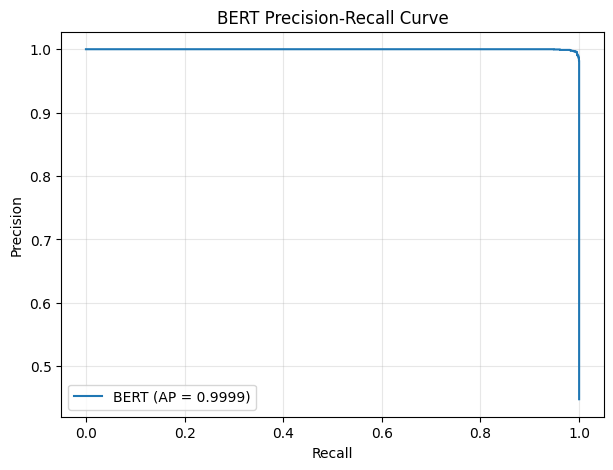

In [42]:
# Calculate Precision-Recall curve
precision_curve, recall_curve, thresholds = precision_recall_curve(
    bert_true_labels,
    bert_fake_prob
)

# Average Precision score
bert_ap = average_precision_score(
    bert_true_labels,
    bert_fake_prob
)

print("BERT Average Precision:", bert_ap)

# Plot Precision-Recall curve
plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"BERT (AP = {bert_ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("BERT Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
bert_results_summary = pd.DataFrame({
    "Model": ["BERT"],
    "Test_Loss": [bert_test_results["eval_loss"]],
    "Accuracy": [bert_test_results["eval_accuracy"]],
    "Precision": [bert_test_results["eval_precision"]],
    "Recall": [bert_test_results["eval_recall"]],
    "F1": [bert_test_results["eval_f1"]],
    "ROC_AUC": [bert_roc_auc],
    "Average_Precision": [bert_ap],
    "Best_Validation_F1": [bert_trainer.state.best_metric],
    "Best_Checkpoint": [bert_trainer.state.best_model_checkpoint]
})

bert_results_summary.to_csv(
    "/kaggle/working/bert_results_summary.csv",
    index=False
)

bert_results_summary

,Model,Test_Loss,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision,Best_Validation_F1,Best_Checkpoint
0,BERT,0.041227,0.995695,0.995696,0.995695,0.995695,0.999905,0.999882,0.994578,/kaggle/working/bert_results/checkpoint-3136


In [44]:
bert_prediction_results = test_df.copy()

bert_prediction_results["bert_prediction"] = bert_pred_labels
bert_prediction_results["bert_fake_probability"] = bert_fake_prob
bert_prediction_results["correct"] = (
    bert_prediction_results["label"] ==
    bert_prediction_results["bert_prediction"]
)

bert_prediction_results.to_csv(
    "/kaggle/working/bert_test_predictions.csv",
    index=False
)

print("Saved BERT test predictions.")
print(
    "Misclassified articles:",
    (~bert_prediction_results["correct"]).sum()
)

Saved BERT test predictions.
Misclassified articles: 27


## 5. RoBERTa Model Development and Evaluation

In [45]:
roberta_model_name = "FacebookAI/roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)

print("RoBERTa tokenizer loaded successfully.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa tokenizer loaded successfully.


In [46]:
MAX_LENGTH = 512

def tokenize_roberta_texts(texts):
    return roberta_tokenizer(
        texts.tolist(),
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

roberta_train_encodings = tokenize_roberta_texts(train_df["text"])
roberta_val_encodings = tokenize_roberta_texts(val_df["text"])
roberta_test_encodings = tokenize_roberta_texts(test_df["text"])

print("RoBERTa tokenisation complete at 512 tokens.")
print("Training examples:", len(roberta_train_encodings["input_ids"]))
print("Validation examples:", len(roberta_val_encodings["input_ids"]))
print("Test examples:", len(roberta_test_encodings["input_ids"]))

RoBERTa tokenisation complete at 512 tokens.
Training examples: 50172
Validation examples: 6271
Test examples: 6272


In [47]:
roberta_train_dataset = FakeNewsDataset(
    roberta_train_encodings,
    train_df["label"]
)

roberta_val_dataset = FakeNewsDataset(
    roberta_val_encodings,
    val_df["label"]
)

roberta_test_dataset = FakeNewsDataset(
    roberta_test_encodings,
    test_df["label"]
)

print("RoBERTa training dataset:", len(roberta_train_dataset))
print("RoBERTa validation dataset:", len(roberta_val_dataset))
print("RoBERTa test dataset:", len(roberta_test_dataset))

RoBERTa training dataset: 50172
RoBERTa validation dataset: 6271
RoBERTa test dataset: 6272


In [48]:
# Dynamic padding for RoBERTa
roberta_data_collator = DataCollatorWithPadding(
    tokenizer=roberta_tokenizer
)

# Load RoBERTa for binary classification
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=2
)

print("RoBERTa classification model loaded successfully.")#


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa classification model loaded successfully.


In [49]:
roberta_training_args = TrainingArguments(
    output_dir="/kaggle/working/roberta_results",

    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    fp16=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=500,
    save_total_limit=2,
    report_to="none",

    seed=42
)

print("RoBERTa training arguments configured successfully.")

RoBERTa training arguments configured successfully.


In [50]:
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_dataset,
    eval_dataset=roberta_val_dataset,
    processing_class=roberta_tokenizer,
    data_collator=roberta_data_collator,
    compute_metrics=compute_metrics
)

print("RoBERTa Trainer configured successfully.")

RoBERTa Trainer configured successfully.


In [52]:
roberta_train_result = roberta_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.126690,0.029201,0.997130,0.997136,0.997130,0.997129
2,0.045792,0.014647,0.998724,0.998725,0.998724,0.998724
3,0.014408,0.009891,0.999362,0.999362,0.999362,0.999362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [53]:
print("Best checkpoint:", roberta_trainer.state.best_model_checkpoint)
print("Best validation F1:", roberta_trainer.state.best_metric)


Best checkpoint: /kaggle/working/roberta_results/checkpoint-4704
Best validation F1: 0.999362121716348
Current epoch: 3.0
Global training steps: 4704


In [54]:
roberta_test_results = roberta_trainer.evaluate(roberta_test_dataset)

print(roberta_test_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.007651937659829855, 'eval_accuracy': 0.9995216836734694, 'eval_precision': 0.999521718994795, 'eval_recall': 0.9995216836734694, 'eval_f1': 0.9995216756465376, 'eval_runtime': 132.8321, 'eval_samples_per_second': 47.218, 'eval_steps_per_second': 5.902, 'epoch': 3.0}


In [55]:
roberta_predictions = roberta_trainer.predict(roberta_test_dataset)

roberta_pred_labels = np.argmax(
    roberta_predictions.predictions,
    axis=1
)

roberta_true_labels = test_df["label"].to_numpy()

print("Classification Report:")
print(
    classification_report(
        roberta_true_labels,
        roberta_pred_labels,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        roberta_true_labels,
        roberta_pred_labels
    )
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Classification Report:
              precision    recall  f1-score   support

           0     0.9994    0.9997    0.9996      3462
           1     0.9996    0.9993    0.9995      2810

    accuracy                         0.9995      6272
   macro avg     0.9995    0.9995    0.9995      6272
weighted avg     0.9995    0.9995    0.9995      6272


Confusion Matrix:
[[3461    1]
 [   2 2808]]


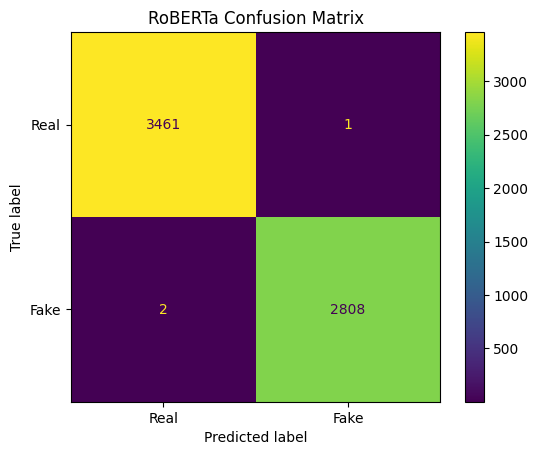

In [56]:
cm = confusion_matrix(
    roberta_true_labels,
    roberta_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(values_format="d")
plt.title("RoBERTa Confusion Matrix")
plt.show()

RoBERTa ROC-AUC: 0.9999975329505295


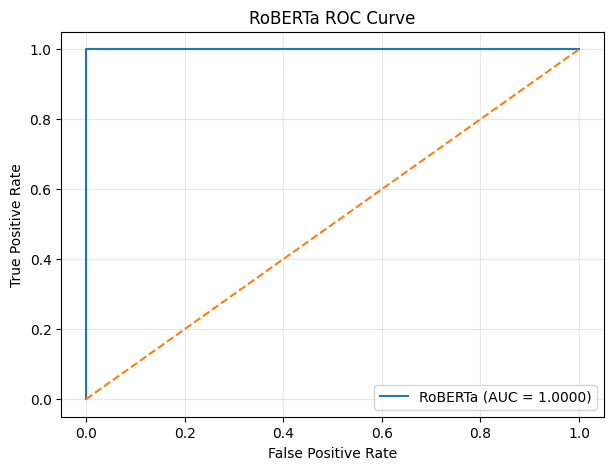

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.special import softmax
import matplotlib.pyplot as plt

# Convert RoBERTa logits to probabilities
roberta_probabilities = softmax(
    roberta_predictions.predictions,
    axis=1
)

# Probability of the positive class (Fake = 1)
roberta_fake_prob = roberta_probabilities[:, 1]

# Calculate ROC curve
roberta_fpr, roberta_tpr, thresholds = roc_curve(
    roberta_true_labels,
    roberta_fake_prob
)

# Calculate ROC-AUC
roberta_roc_auc = roc_auc_score(
    roberta_true_labels,
    roberta_fake_prob
)

print("RoBERTa ROC-AUC:", roberta_roc_auc)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    roberta_fpr,
    roberta_tpr,
    label=f"RoBERTa (AUC = {roberta_roc_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RoBERTa ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

RoBERTa Average Precision: 0.9999969526419055


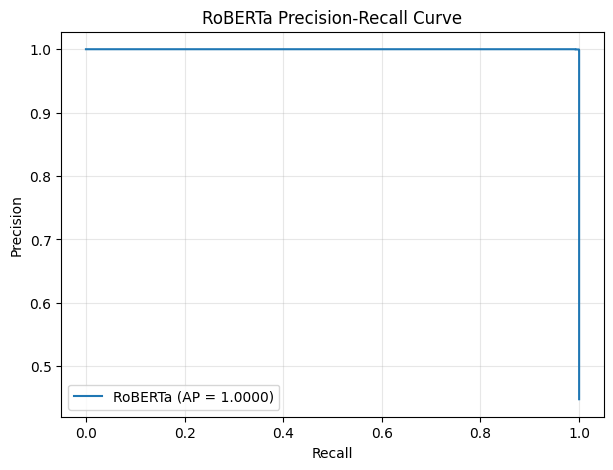

In [58]:
# Calculate Precision-Recall curve
roberta_precision_curve, roberta_recall_curve, thresholds = precision_recall_curve(
    roberta_true_labels,
    roberta_fake_prob
)

# Calculate Average Precision
roberta_ap = average_precision_score(
    roberta_true_labels,
    roberta_fake_prob
)

print("RoBERTa Average Precision:", roberta_ap)

# Plot Precision-Recall curve
plt.figure(figsize=(7, 5))

plt.plot(
    roberta_recall_curve,
    roberta_precision_curve,
    label=f"RoBERTa (AP = {roberta_ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RoBERTa Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [59]:
roberta_results_summary = pd.DataFrame({
    "Model": ["RoBERTa"],
    "Test_Loss": [roberta_test_results["eval_loss"]],
    "Accuracy": [roberta_test_results["eval_accuracy"]],
    "Precision": [roberta_test_results["eval_precision"]],
    "Recall": [roberta_test_results["eval_recall"]],
    "F1": [roberta_test_results["eval_f1"]],
    "ROC_AUC": [roberta_roc_auc],
    "Average_Precision": [roberta_ap],
    "Best_Validation_F1": [roberta_trainer.state.best_metric],
    "Best_Checkpoint": [roberta_trainer.state.best_model_checkpoint]
})

roberta_results_summary.to_csv(
    "/kaggle/working/roberta_results_summary.csv",
    index=False
)

roberta_results_summary

,Model,Test_Loss,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision,Best_Validation_F1,Best_Checkpoint
0,RoBERTa,0.007652,0.999522,0.999522,0.999522,0.999522,0.999998,0.999997,0.999362,/kaggle/working/roberta_results/checkpoint-4704


In [62]:
roberta_prediction_results = test_df.copy()

roberta_prediction_results["roberta_prediction"] = roberta_pred_labels
roberta_prediction_results["roberta_fake_probability"] = roberta_fake_prob
roberta_prediction_results["correct"] = (
    roberta_prediction_results["label"] ==
    roberta_prediction_results["roberta_prediction"]
)

roberta_prediction_results.to_csv(
    "/kaggle/working/roberta_test_predictions.csv",
    index=False
)

print("Saved RoBERTa test predictions.")
print(
    "Misclassified articles:",
    (~roberta_prediction_results["correct"]).sum()
)

Saved RoBERTa test predictions.
Misclassified articles: 3


## 6. ELECTRA Model Development and Evaluation

In [63]:
from transformers import AutoTokenizer

electra_model_name = "google/electra-base-discriminator"

electra_tokenizer = AutoTokenizer.from_pretrained(electra_model_name)

print("ELECTRA tokenizer loaded successfully.")

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ELECTRA tokenizer loaded successfully.


In [64]:
MAX_LENGTH = 512

def tokenize_electra_texts(texts):
    return electra_tokenizer(
        texts.tolist(),
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

electra_train_encodings = tokenize_electra_texts(train_df["text"])
electra_val_encodings = tokenize_electra_texts(val_df["text"])
electra_test_encodings = tokenize_electra_texts(test_df["text"])

print("ELECTRA tokenisation complete at 512 tokens.")
print("Training examples:", len(electra_train_encodings["input_ids"]))
print("Validation examples:", len(electra_val_encodings["input_ids"]))
print("Test examples:", len(electra_test_encodings["input_ids"]))

ELECTRA tokenisation complete at 512 tokens.
Training examples: 50172
Validation examples: 6271
Test examples: 6272


In [65]:
electra_train_dataset = FakeNewsDataset(
    electra_train_encodings,
    train_df["label"]
)

electra_val_dataset = FakeNewsDataset(
    electra_val_encodings,
    val_df["label"]
)

electra_test_dataset = FakeNewsDataset(
    electra_test_encodings,
    test_df["label"]
)

print("ELECTRA training dataset:", len(electra_train_dataset))
print("ELECTRA validation dataset:", len(electra_val_dataset))
print("ELECTRA test dataset:", len(electra_test_dataset))

ELECTRA training dataset: 50172
ELECTRA validation dataset: 6271
ELECTRA test dataset: 6272


In [66]:
# Dynamic padding for ELECTRA
electra_data_collator = DataCollatorWithPadding(
    tokenizer=electra_tokenizer
)

# Load ELECTRA for binary classification
electra_model = AutoModelForSequenceClassification.from_pretrained(
    electra_model_name,
    num_labels=2
)

print("ELECTRA classification model loaded successfully.")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

ELECTRA classification model loaded successfully.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [67]:
electra_training_args = TrainingArguments(
    output_dir="/kaggle/working/electra_results",

    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    fp16=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=500,
    save_total_limit=2,
    report_to="none",

    seed=42
)

print("ELECTRA training arguments configured successfully.")

ELECTRA training arguments configured successfully.


In [68]:
electra_trainer = Trainer(
    model=electra_model,
    args=electra_training_args,
    train_dataset=electra_train_dataset,
    eval_dataset=electra_val_dataset,
    processing_class=electra_tokenizer,
    data_collator=electra_data_collator,
    compute_metrics=compute_metrics
)

print("ELECTRA Trainer configured successfully.")

ELECTRA Trainer configured successfully.


In [70]:
electra_train_result = electra_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.243970,0.123491,0.990592,0.990680,0.990592,0.990584
2,0.176248,0.057616,0.995376,0.995376,0.995376,0.995375
3,0.033163,0.061952,0.996013,0.996013,0.996013,0.996013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

In [71]:
print("Best checkpoint:", electra_trainer.state.best_model_checkpoint)
print("Best validation F1:", electra_trainer.state.best_metric)

Best checkpoint: /kaggle/working/electra_results/checkpoint-4704
Best validation F1: 0.9960131932800725
Current epoch: 3.0
Global training steps: 4704


In [72]:
electra_test_results = electra_trainer.evaluate(
    electra_test_dataset
)

print(electra_test_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.052086908370256424, 'eval_accuracy': 0.9964923469387755, 'eval_precision': 0.9964962778025958, 'eval_recall': 0.9964923469387755, 'eval_f1': 0.9964917500025682, 'eval_runtime': 134.3765, 'eval_samples_per_second': 46.675, 'eval_steps_per_second': 5.834, 'epoch': 3.0}


In [73]:
# Get ELECTRA predictions on the test set
electra_predictions = electra_trainer.predict(electra_test_dataset)

# Convert logits to predicted labels
electra_pred_labels = np.argmax(
    electra_predictions.predictions,
    axis=1
)

# True labels
electra_true_labels = test_df["label"].to_numpy()

print("Classification Report:")
print(
    classification_report(
        electra_true_labels,
        electra_pred_labels,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        electra_true_labels,
        electra_pred_labels
    )
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Classification Report:
              precision    recall  f1-score   support

           0     0.9954    0.9983    0.9968      3462
           1     0.9979    0.9943    0.9961      2810

    accuracy                         0.9965      6272
   macro avg     0.9966    0.9963    0.9965      6272
weighted avg     0.9965    0.9965    0.9965      6272


Confusion Matrix:
[[3456    6]
 [  16 2794]]


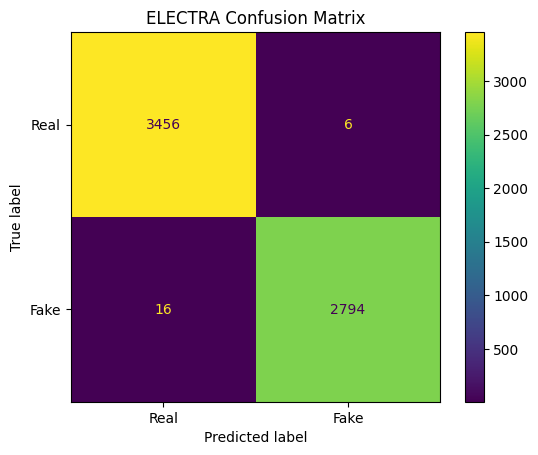

In [74]:
cm = confusion_matrix(
    electra_true_labels,
    electra_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(values_format="d")
plt.title("ELECTRA Confusion Matrix")
plt.show()


ELECTRA ROC-AUC: 0.9999245494036936


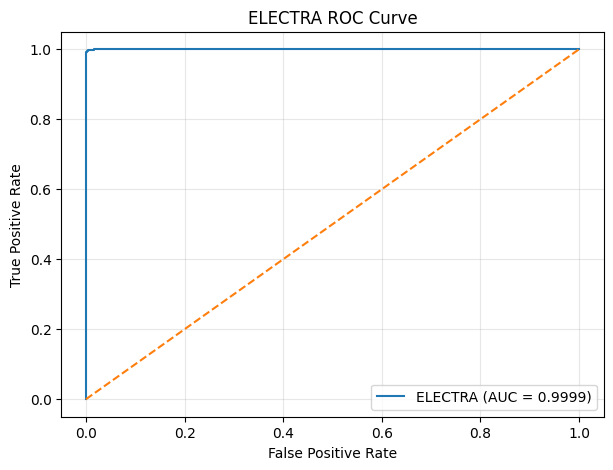

In [75]:
# Convert ELECTRA logits to probabilities
electra_probabilities = softmax(
    electra_predictions.predictions,
    axis=1
)

# Probability of positive class (Fake = 1)
electra_fake_prob = electra_probabilities[:, 1]

# Calculate ROC curve
electra_fpr, electra_tpr, thresholds = roc_curve(
    electra_true_labels,
    electra_fake_prob
)

# Calculate ROC-AUC
electra_roc_auc = roc_auc_score(
    electra_true_labels,
    electra_fake_prob
)

print("ELECTRA ROC-AUC:", electra_roc_auc)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    electra_fpr,
    electra_tpr,
    label=f"ELECTRA (AUC = {electra_roc_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ELECTRA ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


ELECTRA Average Precision: 0.9999078667663569


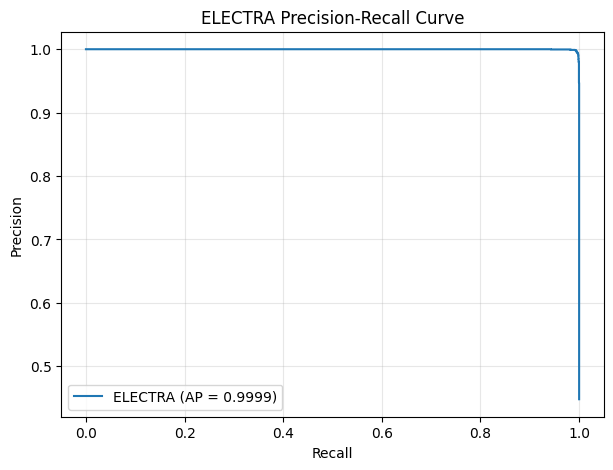

In [76]:
# Calculate Precision-Recall curve
electra_precision_curve, electra_recall_curve, thresholds = precision_recall_curve(
    electra_true_labels,
    electra_fake_prob
)

# Calculate Average Precision
electra_ap = average_precision_score(
    electra_true_labels,
    electra_fake_prob
)

print("ELECTRA Average Precision:", electra_ap)

# Plot Precision-Recall curve
plt.figure(figsize=(7, 5))

plt.plot(
    electra_recall_curve,
    electra_precision_curve,
    label=f"ELECTRA (AP = {electra_ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("ELECTRA Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [78]:
electra_results_summary = pd.DataFrame({
    "Model": ["ELECTRA"],
    "Test_Loss": [electra_test_results["eval_loss"]],
    "Accuracy": [electra_test_results["eval_accuracy"]],
    "Precision": [electra_test_results["eval_precision"]],
    "Recall": [electra_test_results["eval_recall"]],
    "F1": [electra_test_results["eval_f1"]],
    "ROC_AUC": [electra_roc_auc],
    "Average_Precision": [electra_ap],
    "Best_Validation_F1": [electra_trainer.state.best_metric],
    "Best_Checkpoint": [electra_trainer.state.best_model_checkpoint]
})

electra_results_summary.to_csv(
    "/kaggle/working/electra_results_summary.csv",
    index=False
)

electra_results_summary

,Model,Test_Loss,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision,Best_Validation_F1,Best_Checkpoint
0,ELECTRA,0.052087,0.996492,0.996496,0.996492,0.996492,0.999925,0.999908,0.996013,/kaggle/working/electra_results/checkpoint-4704


In [79]:
electra_prediction_results = test_df.copy()

electra_prediction_results["electra_prediction"] = electra_pred_labels
electra_prediction_results["electra_fake_probability"] = electra_fake_prob

electra_prediction_results["correct"] = (
    electra_prediction_results["label"] ==
    electra_prediction_results["electra_prediction"]
)

electra_prediction_results.to_csv(
    "/kaggle/working/electra_test_predictions.csv",
    index=False
)

print("Saved ELECTRA test predictions.")
print(
    "Misclassified articles:",
    (~electra_prediction_results["correct"]).sum()
)

Saved ELECTRA test predictions.
Misclassified articles: 22


## 7. Transformer Model Comparison

In [80]:
transformer_comparison = pd.concat(
    [
        bert_results_summary,
        roberta_results_summary,
        electra_results_summary
    ],
    ignore_index=True
)

# Remove checkpoint path from the main comparison table
comparison_table = transformer_comparison[
    [
        "Model",
        "Test_Loss",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "Average_Precision",
        "Best_Validation_F1"
    ]
].copy()

comparison_table.to_csv(
    "/kaggle/working/transformer_model_comparison.csv",
    index=False
)

comparison_table

,Model,Test_Loss,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision,Best_Validation_F1
0,BERT,0.041227,0.995695,0.995696,0.995695,0.995695,0.999905,0.999882,0.994578
1,RoBERTa,0.007652,0.999522,0.999522,0.999522,0.999522,0.999998,0.999997,0.999362
2,ELECTRA,0.052087,0.996492,0.996496,0.996492,0.996492,0.999925,0.999908,0.996013


In [81]:
comparison_table["Misclassified"] = [
    (~bert_prediction_results["correct"]).sum(),
    (~roberta_prediction_results["correct"]).sum(),
    (~electra_prediction_results["correct"]).sum()
]

comparison_table.to_csv(
    "/kaggle/working/transformer_model_comparison.csv",
    index=False
)

comparison_table

,Model,Test_Loss,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision,Best_Validation_F1,Misclassified
0,BERT,0.041227,0.995695,0.995696,0.995695,0.995695,0.999905,0.999882,0.994578,27
1,RoBERTa,0.007652,0.999522,0.999522,0.999522,0.999522,0.999998,0.999997,0.999362,3
2,ELECTRA,0.052087,0.996492,0.996496,0.996492,0.996492,0.999925,0.999908,0.996013,22


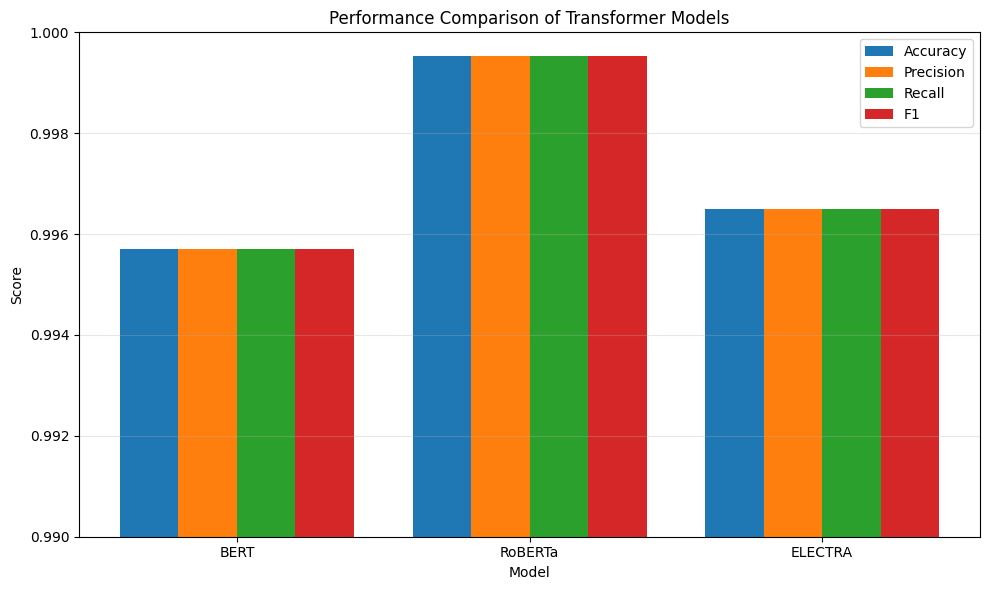

In [82]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
models = comparison_table["Model"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        comparison_table[metric],
        width,
        label=metric
    )

plt.xticks(x, models)
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Performance Comparison of Transformer Models")

# Focus on the high-performing range
plt.ylim(0.99, 1.0)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

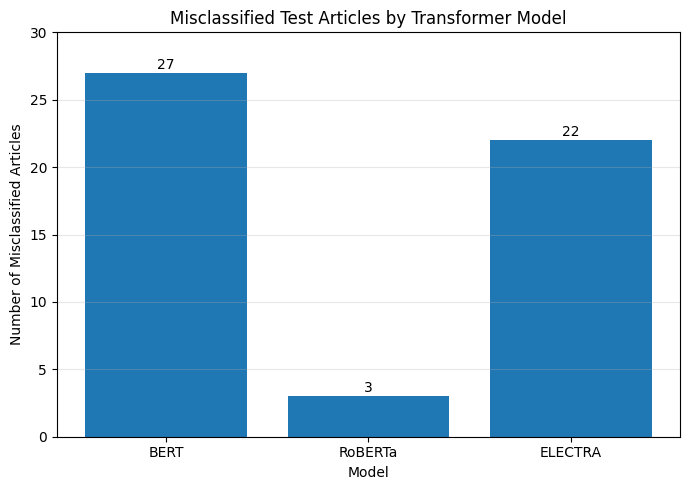

In [83]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    comparison_table["Model"],
    comparison_table["Misclassified"]
)

plt.xlabel("Model")
plt.ylabel("Number of Misclassified Articles")
plt.title("Misclassified Test Articles by Transformer Model")

# Add exact numbers above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{int(height)}",
        ha="center"
    )

plt.ylim(0, 30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

## 8. RoBERTa Error Analysis

In [84]:
roberta_errors = roberta_prediction_results[
    roberta_prediction_results["correct"] == False
].copy()

print("Number of RoBERTa errors:", len(roberta_errors))

roberta_errors[
    [
        "title",
        "label",
        "roberta_prediction",
        "roberta_fake_probability"
    ]
]

Number of RoBERTa errors: 3


,title,label,roberta_prediction,roberta_fake_probability
61870,Trump Supreme Court nominee Gorsuch seen in the mold of Scalia,0,1,0.999965
41040,PENNSYLVANIA GUN STORE tells customers “Muslims and Hillary supporters are not welcome”,1,0,0.031130
40672,BRILLIANT NEWT GINGRICH: Here’s Why Trump Should NOT Trust Intel Community Right Now [Video],1,0,0.000036


## 9. SHAP Explainability Analysis

In [86]:
# All correctly classified RoBERTa predictions
roberta_correct = roberta_prediction_results[
    roberta_prediction_results["correct"] == True
].copy()

# Sample 10 correctly classified Real articles
correct_real = roberta_correct[
    roberta_correct["label"] == 0
].sample(
    n=10,
    random_state=42
).copy()

# Sample 10 correctly classified Fake articles
correct_fake = roberta_correct[
    roberta_correct["label"] == 1
].sample(
    n=10,
    random_state=42
).copy()

# Include all 3 misclassified articles
incorrect_examples = roberta_errors.copy()

# Add explanation groups
correct_real["explanation_group"] = "Correct Real"
correct_fake["explanation_group"] = "Correct Fake"
incorrect_examples["explanation_group"] = "Misclassified"

# Combine into final explainability sample
roberta_explainability_sample = pd.concat(
    [
        correct_real,
        correct_fake,
        incorrect_examples
    ],
    ignore_index=True
)

print("Total explainability sample:", len(roberta_explainability_sample))
print(
    roberta_explainability_sample[
        "explanation_group"
    ].value_counts()
)

,title,label,roberta_prediction,roberta_fake_probability,correct
61042,Trump to nominate Elaine Duke as Homeland Security deputy secretary,0,0,0.000001,True
53893,"Hillary Clinton Made History, but Bernie Sanders Stubbornly Ignored It - The New York Times",0,0,0.000001,True
61698,"In rare foreign trip, Assad flies to Moscow to meet with Putin",0,0,0.000001,True
19838,SHOCKING TAXPAYER TAB FOR OBAMA’S GOLF Trips And Fundraisers In February And March 2015,1,1,0.999999,True
23491,"TERMINALLY ILL FORMER MISS WI: “Until my last breath, I will use this voice to tell who Mr. Trump really is” [VIDEO]",1,1,0.999998,True
8645,"MELANIA Thanks Troops For Sacrifices At Easter Egg Roll…FLASHBACK To 2016: “Peanut Crew” Had To Remind Michelle Obama To Mention Troops, After Using Easter Speech To Brag About All Of Their Accomplishments [VIDEO]",1,1,0.999998,True
61870,Trump Supreme Court nominee Gorsuch seen in the mold of Scalia,0,1,0.999965,False
41040,PENNSYLVANIA GUN STORE tells customers “Muslims and Hillary supporters are not welcome”,1,0,0.031130,False
40672,BRILLIANT NEWT GINGRICH: Here’s Why Trump Should NOT Trust Intel Community Right Now [Video],1,0,0.000036,False


In [87]:
def roberta_predict(texts):
    # Tokenise text
    inputs = roberta_tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    # Move inputs to same device as model
    device = next(roberta_model.parameters()).device
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    roberta_model.eval()

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    # Convert logits to probabilities
    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    return probabilities.cpu().numpy()

print("RoBERTa SHAP prediction function ready.")

RoBERTa SHAP prediction function ready.


In [88]:
test_text = [
    roberta_explainability_sample.iloc[0]["text"]
]

test_probability = roberta_predict(test_text)

print("Real probability:", test_probability[0][0])
print("Fake probability:", test_probability[0][1])
print(
    "Predicted class:",
    np.argmax(test_probability[0])
)

Real probability: 0.9999988
Fake probability: 1.1981103e-06
Predicted class: 0


In [89]:
# Create text masker using the RoBERTa tokenizer
roberta_masker = shap.maskers.Text(
    roberta_tokenizer
)

# Create SHAP explainer
roberta_explainer = shap.Explainer(
    roberta_predict,
    roberta_masker,
    output_names=["Real", "Fake"]
)

print("RoBERTa SHAP explainer created successfully.")

RoBERTa SHAP explainer created successfully.


In [93]:
# First RoBERTa misclassified article
error_text = roberta_errors.iloc[0]["text"]

error_shap_values = roberta_explainer(
    [error_text],
    max_evals=500
)

print("SHAP explanation for misclassified article generated.")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.72s/it]               

SHAP explanation for misclassified article generated.


In [97]:
def truncate_for_roberta(text):
    encoded = roberta_tokenizer(
        text,
        truncation=True,
        max_length=512,
        add_special_tokens=True
    )

    return roberta_tokenizer.decode(
        encoded["input_ids"],
        skip_special_tokens=True
    )

In [96]:
error_text_512 = truncate_for_roberta(
    roberta_errors.iloc[0]["text"]
)

print(
    "Tokens after truncation:",
    len(roberta_tokenizer.encode(error_text_512))
)

Tokens after truncation: 512


In [100]:
# Truncate all three misclassified articles to RoBERTa's input limit
roberta_error_texts_512 = [
    truncate_for_roberta(text)
    for text in roberta_errors["text"]
]

# Check token lengths
for i, text in enumerate(roberta_error_texts_512):
    token_count = len(
        roberta_tokenizer.encode(
            text,
            add_special_tokens=True
        )
    )

    print(f"Error {i + 1}: {token_count} tokens")

Error 1: 512 tokens
Error 2: 512 tokens
Error 3: 79 tokens


In [101]:
roberta_error_shap_values = roberta_explainer(
    roberta_error_texts_512,
    max_evals=500
)

print("SHAP explanations generated for all 3 RoBERTa errors.")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:36, 12.00s/it]                       

SHAP explanations generated for all 3 RoBERTa errors.


In [103]:
shap.plots.text(
    roberta_error_shap_values[1, :, 1]
)

In [104]:
shap.plots.text(
    roberta_error_shap_values[2, :, 1]
)

In [106]:
import numpy as np
import pandas as pd

def get_top_shap_tokens(shap_values, example_index, class_index=1, top_n=15):
    
    tokens = np.array(shap_values[example_index].data)
    values = np.array(
        shap_values[example_index].values[:, class_index]
    )

    token_df = pd.DataFrame({
        "Token": tokens,
        "SHAP_Value": values
    })

    # Remove empty/whitespace tokens
    token_df = token_df[
        token_df["Token"].astype(str).str.strip() != ""
    ]

    # Rank by absolute contribution
    token_df["Absolute_SHAP"] = token_df["SHAP_Value"].abs()

    return token_df.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).head(top_n)


for i in range(3):
    print(f"\n{'=' * 70}")
    print(f"MISCLASSIFIED ARTICLE {i + 1}")
    print("Title:", roberta_errors.iloc[i]["title"])
    print(
        "True:",
        "Fake" if roberta_errors.iloc[i]["label"] == 1 else "Real"
    )
    print(
        "Predicted:",
        "Fake" if roberta_errors.iloc[i]["roberta_prediction"] == 1 else "Real"
    )
    print("=" * 70)

    display(
        get_top_shap_tokens(
            roberta_error_shap_values,
            i,
            class_index=1,
            top_n=15
        )
    )


MISCLASSIFIED ARTICLE 1
Title: Trump Supreme Court nominee Gorsuch seen in the mold of Scalia
True: Real
Predicted: Fake


,Token,SHAP_Value,Absolute_SHAP
393,”,-0.033604,0.033604
396,said,-0.033604,0.033604
395,Gorsuch,-0.033604,0.033604
394,”,-0.033604,0.033604
128,For,0.031667,0.031667
126,T,0.031667,0.031667
127,MISS,0.031667,0.031667
269,CLUS,0.030573,0.030573
268,EX,0.030573,0.030573
270,IVE,0.030573,0.030573



MISCLASSIFIED ARTICLE 2
Title: PENNSYLVANIA GUN STORE tells customers “Muslims and Hillary supporters are not welcome”
True: Fake
Predicted: Real


,Token,SHAP_Value,Absolute_SHAP
406,,0.013969,0.013969
403,Â,0.013969,0.013969
404,â,0.013969,0.013969
405,â,0.013969,0.013969
327,,-0.010321,0.010321
326,,-0.010321,0.010321
325,â,-0.010321,0.010321
324,They,-0.010321,0.010321
64,.,0.010104,0.010104
63,welcome,0.009782,0.009782



MISCLASSIFIED ARTICLE 3
Title: BRILLIANT NEWT GINGRICH: Here’s Why Trump Should NOT Trust Intel Community Right Now [Video]
True: Fake
Predicted: Real


,Token,SHAP_Value,Absolute_SHAP
30,Reuters,-0.506590,0.506590
29,(,-0.105630,0.105630
39,Sunday,-0.098076,0.098076
28,WASHINGTON,-0.068881,0.068881
31,),-0.049774,0.049774
46,Republican,-0.045247,0.045247
25,elect,-0.031180,0.031180
41,a,-0.030771,0.030771
38,on,-0.026248,0.026248
27,:,0.020431,0.020431


In [116]:
final_texts_512 = [
    truncate_for_roberta(text)
    for text in roberta_final_explainability_sample["text"]
]

print("Texts prepared:", len(final_texts_512))

token_lengths = [
    len(
        roberta_tokenizer.encode(
            text,
            add_special_tokens=True
        )
    )
    for text in final_texts_512
]

print("Maximum token length:", max(token_lengths))
print("Minimum token length:", min(token_lengths))

Texts prepared: 23
Maximum token length: 512
Minimum token length: 73


In [117]:
roberta_final_shap_values = roberta_explainer(
    final_texts_512,
    max_evals=500
)

print("SHAP explanations generated for all 23 examples.")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   9%|▊         | 2/23 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  17%|█▋        | 4/23 [00:34<02:33,  8.09s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  96%|█████████▌| 22/23 [04:08<00:13, 13.75s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 24it [04:28, 12.18s/it]                        

SHAP explanations generated for all 23 examples.


In [118]:
final_shap_rows = []

for i in range(len(roberta_final_explainability_sample)):
    
    row = roberta_final_explainability_sample.iloc[i]
    
    if not row["correct"]:
        group = "Misclassified"
    elif row["label"] == 0:
        group = "Correct Real"
    else:
        group = "Correct Fake"

    token_df = get_top_shap_tokens(
        roberta_final_shap_values,
        i,
        class_index=1,   
        top_n=15
    )

    for _, token_row in token_df.iterrows():
        final_shap_rows.append({
            "Group": group,
            "Title": row["title"],
            "True_Label": row["label"],
            "Prediction": row["roberta_prediction"],
            "Fake_Probability": row["roberta_fake_probability"],
            "Token": token_row["Token"],
            "SHAP_Value": token_row["SHAP_Value"],
            "Absolute_SHAP": token_row["Absolute_SHAP"]
        })

final_shap_summary = pd.DataFrame(final_shap_rows)

print(
    "Total SHAP feature records:",
    len(final_shap_summary)
)

final_shap_summary.head()

Total SHAP feature records: 345


,Group,Title,True_Label,Prediction,Fake_Probability,Token,SHAP_Value,Absolute_SHAP
0,Correct Real,Trump to nominate Elaine Duke as Homeland Security deputy secretary,0,0,0.000001,Reuters,-0.135368,0.135368
1,Correct Real,Trump to nominate Elaine Duke as Homeland Security deputy secretary,0,0,0.000001,WASHINGTON,-0.090907,0.090907
2,Correct Real,Trump to nominate Elaine Duke as Homeland Security deputy secretary,0,0,0.000001,House,-0.075729,0.075729
3,Correct Real,Trump to nominate Elaine Duke as Homeland Security deputy secretary,0,0,0.000001,on,-0.067383,0.067383
4,Correct Real,Trump to nominate Elaine Duke as Homeland Security deputy secretary,0,0,0.000001,Monday,-0.054673,0.054673


In [119]:
final_shap_summary.to_csv(
    "/kaggle/working/roberta_final_shap_summary.csv",
    index=False
)

roberta_final_explainability_sample.to_csv(
    "/kaggle/working/roberta_final_explainability_sample.csv",
    index=False
)

print("Final RoBERTa SHAP files saved.")

Final RoBERTa SHAP files saved.


In [120]:
print("Final SHAP summary shape:", final_shap_summary.shape)
print(final_shap_summary["Group"].value_counts())

Final SHAP summary shape: (345, 8)
Group
Correct Real     150
Correct Fake     150
Misclassified     45
Name: count, dtype: int64
